In [3]:
# The code in this block comes directly from data_sort_and_split.ipynb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

heart_data = pd.read_csv("heart.csv")

heart_data['Sex_F'] = heart_data['Sex'].map({'M': 0, 'F': 1})
heart_data['ExerciseAngina'] = heart_data['ExerciseAngina'].map({'N': 0, 'Y': 1})
heart_data = heart_data.drop(columns=['Sex'])

heart_data['ChestPainType'] = pd.Categorical(heart_data['ChestPainType'], categories=['ASY', 'ATA', 'NAP', 'TA'])
heart_data['RestingECG'] = pd.Categorical(heart_data['RestingECG'], categories=['Normal', 'LVH', 'ST'])
heart_data['ST_Slope'] = pd.Categorical(heart_data['ST_Slope'], categories=['Up', 'Flat', 'Down'])

categorical_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']
heart_data = pd.get_dummies(heart_data, columns=categorical_cols, drop_first=True, dtype=int)

feature_matrix = heart_data.drop("HeartDisease", axis=1)
target_labels = heart_data["HeartDisease"]

features_train, features_test, targets_train, targets_test = train_test_split(
    feature_matrix,
    target_labels,
    test_size=0.20,
    random_state=42,
    stratify= target_labels
)

# Scaling performed to avoid features with larger ranges being seen as more significant to model
# Furthermore, it prevents data leakage by fitting to training data only.

scaler = StandardScaler()

# WWe 'fit' only on training data to prevent data leakage from the test set.
scaler.fit(features_train)

# We transform both sets using the training parameters so the scale is consistent.
features_train_scaled = scaler.transform(features_train)
features_test_scaled = scaler.transform(features_test)



In [13]:
# Single Hidden Layer Model Creation
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer

# Setting a seed so our model returns the same results everytime
tf.random.set_seed(1)

#Actual model creation, but it has no layers yet
neural_network_model = Sequential()

#Input layer created with 15 neurons, one for every feature in our cleaned dataset
input_layer = InputLayer(shape=(15,))
neural_network_model.add(input_layer)

# Creating and adding hidden layer
# using the ((2/3(input layer size)) + 1 + (output layer size)) principle for number of neurons.
hidden_layer = Dense(11, activation= "relu")
neural_network_model.add(hidden_layer)

output_layer = Dense(1, activation='sigmoid')
neural_network_model.add(output_layer)

neural_network_model.compile(optimizer='adam', loss='binary_crossentropy',)

In [14]:
#Training the Neural Networks

# Defining Early Stopping to prevent overfitting on our 900-row dataset
# monitor='val_loss': We watch the error on the 20% validation set, not already seen data
# patience=5: If the error doesn't improve for 5 straight epochs, we stop.
# restore_best_weights=True: This rolls the model back to its peak performance moment.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience= 8,
    restore_best_weights=True
)

# Training the model
# We use a batch_size of 16 to give the Adam optimizer more updates per epoch.
# We set epochs to 80, but Early Stopping will likely stop it much sooner (the 30-50 range)
# We use a validation split here to monitor performance on unseen data
# DURING training, so we can stop before the model overfits
neural_network_model.fit(
    features_train_scaled,
    targets_train,
    epochs=80,
    batch_size=16, # The number of rows the model trains itself on before testing itself
    validation_split=0.2, #Like a practice quiz
    callbacks=[early_stop])

Epoch 1/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7643 - val_loss: 0.6895
Epoch 2/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6751 - val_loss: 0.6280
Epoch 3/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6064 - val_loss: 0.5797
Epoch 4/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5499 - val_loss: 0.5410
Epoch 5/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5027 - val_loss: 0.5106
Epoch 6/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4634 - val_loss: 0.4868
Epoch 7/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4312 - val_loss: 0.4682
Epoch 8/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4048 - val_loss: 0.4545
Epoch 9/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3836 - val_loss: 0.4449
Epoch 10/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3671 - val_loss: 0.4382
Epoch 11/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3540 - val_loss: 0.4337
Epoch 12/80
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3434 - val_lo

In [15]:
#Predicting with the models and turning probabilities into 1s and 0s

#Making the models predict based on the scaled testing data
model_probabilities = neural_network_model.predict(features_test_scaled)

#Converting to 1s and 0s
# Sigmoid outputs are between 0-1, but Precision/Recall/F1 need discrete categories.
model_predictions = (model_probabilities >= 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [23]:
 #Retreiving Metrics for each mode, then comparing them
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, precision_score, confusion_matrix

metrics_used = ["Accuracy", "Recall", "Precision", "f-1 Score", "ROC-AUC Score"]

model_metrics = []
model_metrics.append(accuracy_score(targets_test, model_predictions))
model_metrics.append(recall_score(targets_test, model_predictions))
model_metrics.append(precision_score(targets_test, model_predictions))
model_metrics.append(f1_score(targets_test, model_predictions))
model_metrics.append(roc_auc_score(targets_test, model_probabilities))




print("Neural Network Model Performance:")
print(f"  Accuracy:  {model_metrics[0]:.4f}")
print(f"  Precision: {model_metrics[2]:.4f}")
print(f"  Recall:    {model_metrics[1]:.4f}")
print(f"  F1-Score:  {model_metrics[3]:.4f}")
print(f"  ROC-AUC:   {model_metrics[4]:.4f}")

Neural Network Model Performance:
  Accuracy:  0.8913
  Precision: 0.9020
  Recall:    0.9020
  F1-Score:  0.9020
  ROC-AUC:   0.9261

Confusion Matrix:
[[72 10]
 [10 92]]


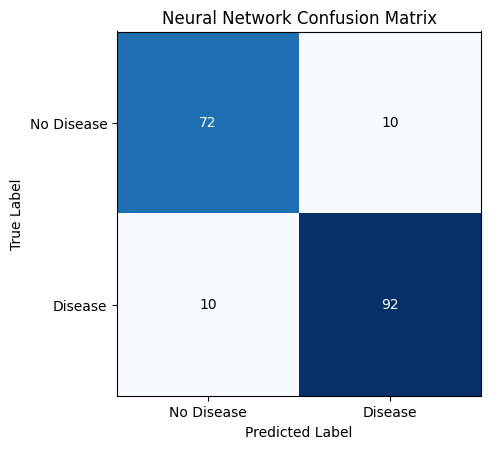

In [26]:
# Why: We generate a standard confusion matrix array to identify True/False Positives and Negatives.
cm = confusion_matrix(targets_test, model_predictions)

# Why: figsize=(5,5) and the 2x2 nature of the data naturally create a square appearance.
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Why: Adding labels to the axes makes the matrix readable for medical professionals.
classes = ['No Disease', 'Disease']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Why: We loop through the matrix to place the actual counts in the center of each square.
# Why: The color 'white' or 'black' is chosen based on the background darkness for contrast.
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Neural Network Confusion Matrix')
plt.tight_layout()
plt.show()